<a href="https://colab.research.google.com/github/masterAristocats/Proc-Sin-Trabalho-Extra/blob/main/examples/beamformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###Exemplo de utilização

## Objetivo

Implementar a função `beamformer(x, positions, steering_direction, wavelength)` responsável por realizar o beamforming convencional (Delay-and-Sum).


In [1]:
!git clone https://github.com/masterAristocats/Proc-Sin-Trabalho-Extra.git

Cloning into 'Proc-Sin-Trabalho-Extra'...
remote: Enumerating objects: 243, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (78/78), done.
remote: Total 243 (delta 30), reused 2 (delta 2), pack-reused 162 (from 1)
Receiving objects: 100% (243/243), 14.03 MiB | 13.51 MiB/s, done.
Resolving deltas: 100% (99/99), done.


In [2]:
%cd Proc-Sin-Trabalho-Extra

!ls src

/content/Proc-Sin-Trabalho-Extra
beamformer.py	generate_uca.py   generate_ula.py  steering_vector.py
beampattern.py	generate_ucya.py  generate_upa.py


In [3]:
import numpy as np

from src.generate_ula import generate_ula
from src.beamformer import beamformer
from src.steering_vector import steering_vector

In [4]:
wavelength = 1

M = 8
d = wavelength / 2

positions = generate_ula(M, d)

# Sinal recebido
x = np.ones(M, dtype=complex)

# Direção de observação
direction = (
    np.deg2rad(0),
    np.deg2rad(0)
)

y = beamformer(
    x,
    positions,
    direction,
    wavelength
)

print("Saída do beamformer:")
print(y)

Saída do beamformer:
6.123233995736767e-17j


## Sinais Recebidos

Neste exemplo todos os sensores recebem sinais com mesma amplitude e fase. O gráfico abaixo apresenta o módulo do vetor de entrada do beamformer.

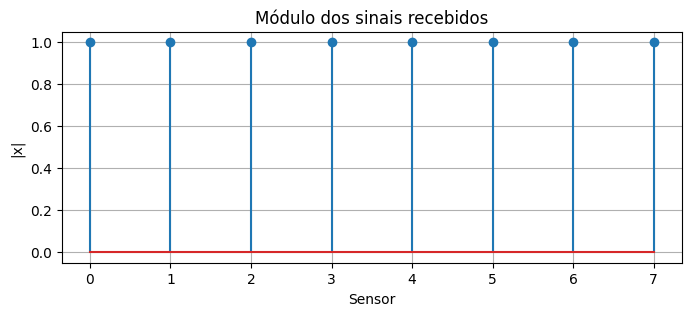

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,3))

plt.stem(np.abs(x))

plt.title("Módulo dos sinais recebidos")

plt.xlabel("Sensor")
plt.ylabel("|x|")

plt.grid(True)

plt.show()

## Vetor de Pesos

Os pesos utilizados pelo beamformer convencional são obtidos a partir do vetor diretor normalizado pelo número de sensores.

O gráfico abaixo apresenta o módulo dos pesos utilizados.

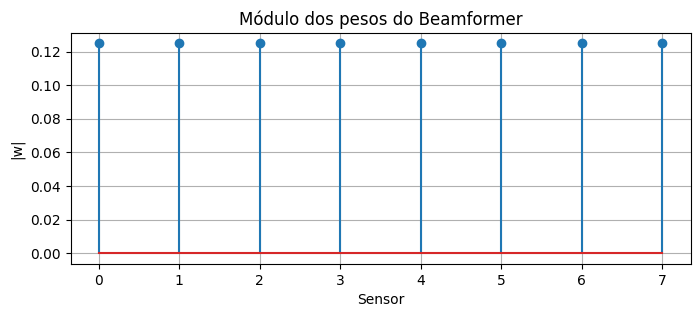

In [6]:
a = steering_vector(
    positions,
    direction[0],
    direction[1],
    wavelength
)

w = a / M

plt.figure(figsize=(8,3))

plt.stem(np.abs(w))

plt.title("Módulo dos pesos do Beamformer")

plt.xlabel("Sensor")
plt.ylabel("|w|")

plt.grid(True)

plt.show()

## Fase dos Pesos

Além da amplitude, cada peso possui uma fase responsável por compensar os atrasos introduzidos pela propagação da onda.

Essa compensação permite alinhar os sinais provenientes da direção desejada antes da soma realizada pelo beamformer.

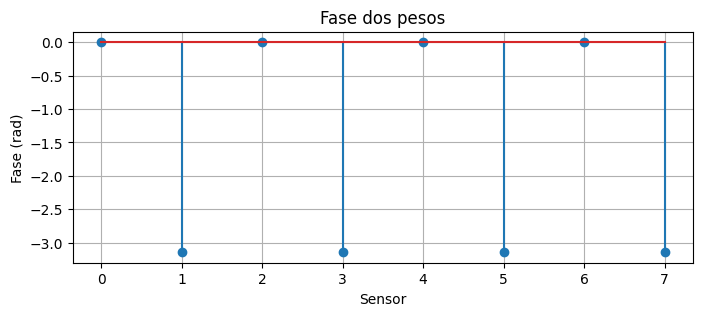

In [7]:
plt.figure(figsize=(8,3))

plt.stem(np.angle(w))

plt.title("Fase dos pesos")

plt.xlabel("Sensor")
plt.ylabel("Fase (rad)")

plt.grid(True)

plt.show()

# Beamformer Convencional (Delay-and-Sum)

## Modelagem Matemática

Considere um vetor contendo os sinais recebidos pelos sensores

\[
\mathbf{x}=
\begin{bmatrix}
x_1\\
x_2\\
\vdots\\
x_M
\end{bmatrix}.
\]

Para uma direção de observação definida pelos ângulos de azimute e elevação, calcula-se inicialmente o vetor diretor

\[
\mathbf a(\theta,\phi).
\]

No beamformer convencional (Delay-and-Sum), os pesos são definidos por

\[
\mathbf w=\frac{\mathbf a(\theta,\phi)}{M},
\]

onde \(M\) representa o número de sensores.

A saída do beamformer é obtida por

\[
y=\mathbf w^H\mathbf x,
\]

em que \((\cdot)^H\) representa o conjugado transposto.

Esse procedimento realiza o alinhamento das fases dos sinais provenientes da direção desejada, aumentando sua contribuição na saída do arranjo.